In [2]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier

# Avaliação
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

# Configurações visuais
sns.set_theme(style="whitegrid", palette="husl")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.dpi"] = 120

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [3]:
df = pd.read_csv("diabetes_prediction_dataset.csv")

display(df.head())

# Dimensões
print(f"\nDimensão do dataset")
print(f"Linhas (pacientes): {df.shape[0]}")
print(f"Colunas (variáveis): {df.shape[1]}")

# Colunas e tipos
print(f"\nColunas e tipos")
print(df.dtypes)

# Valores nulos
print(f"\nValores nulos")
print(df.isnull().sum())

# Balanceamento das classes
print(f"\nDistribuição da variável diabetes")
print(df["diabetes"].value_counts())
print(f"\nPercentual:")
print(df["diabetes"].value_counts(normalize=True).mul(100).round(1))

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0



Dimensão do dataset
Linhas (pacientes): 100000
Colunas (variáveis): 9

Colunas e tipos
gender                     str
age                    float64
hypertension             int64
heart_disease            int64
smoking_history            str
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Valores nulos
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Distribuição da variável diabetes
diabetes
0    91500
1     8500
Name: count, dtype: int64

Percentual:
diabetes
0    91.5
1     8.5
Name: proportion, dtype: float64


C:\Users\Marcello\AppData\Local\Temp\ipykernel_8616\2408009313.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Marcello\AppData\Local\Temp\ipykernel_8616\2408009313.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Marcello\AppData\Local\Temp\ipykernel_8616\2408009313.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Marcello\AppData\Local\Temp\ipykernel_8616\2408009313.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variab

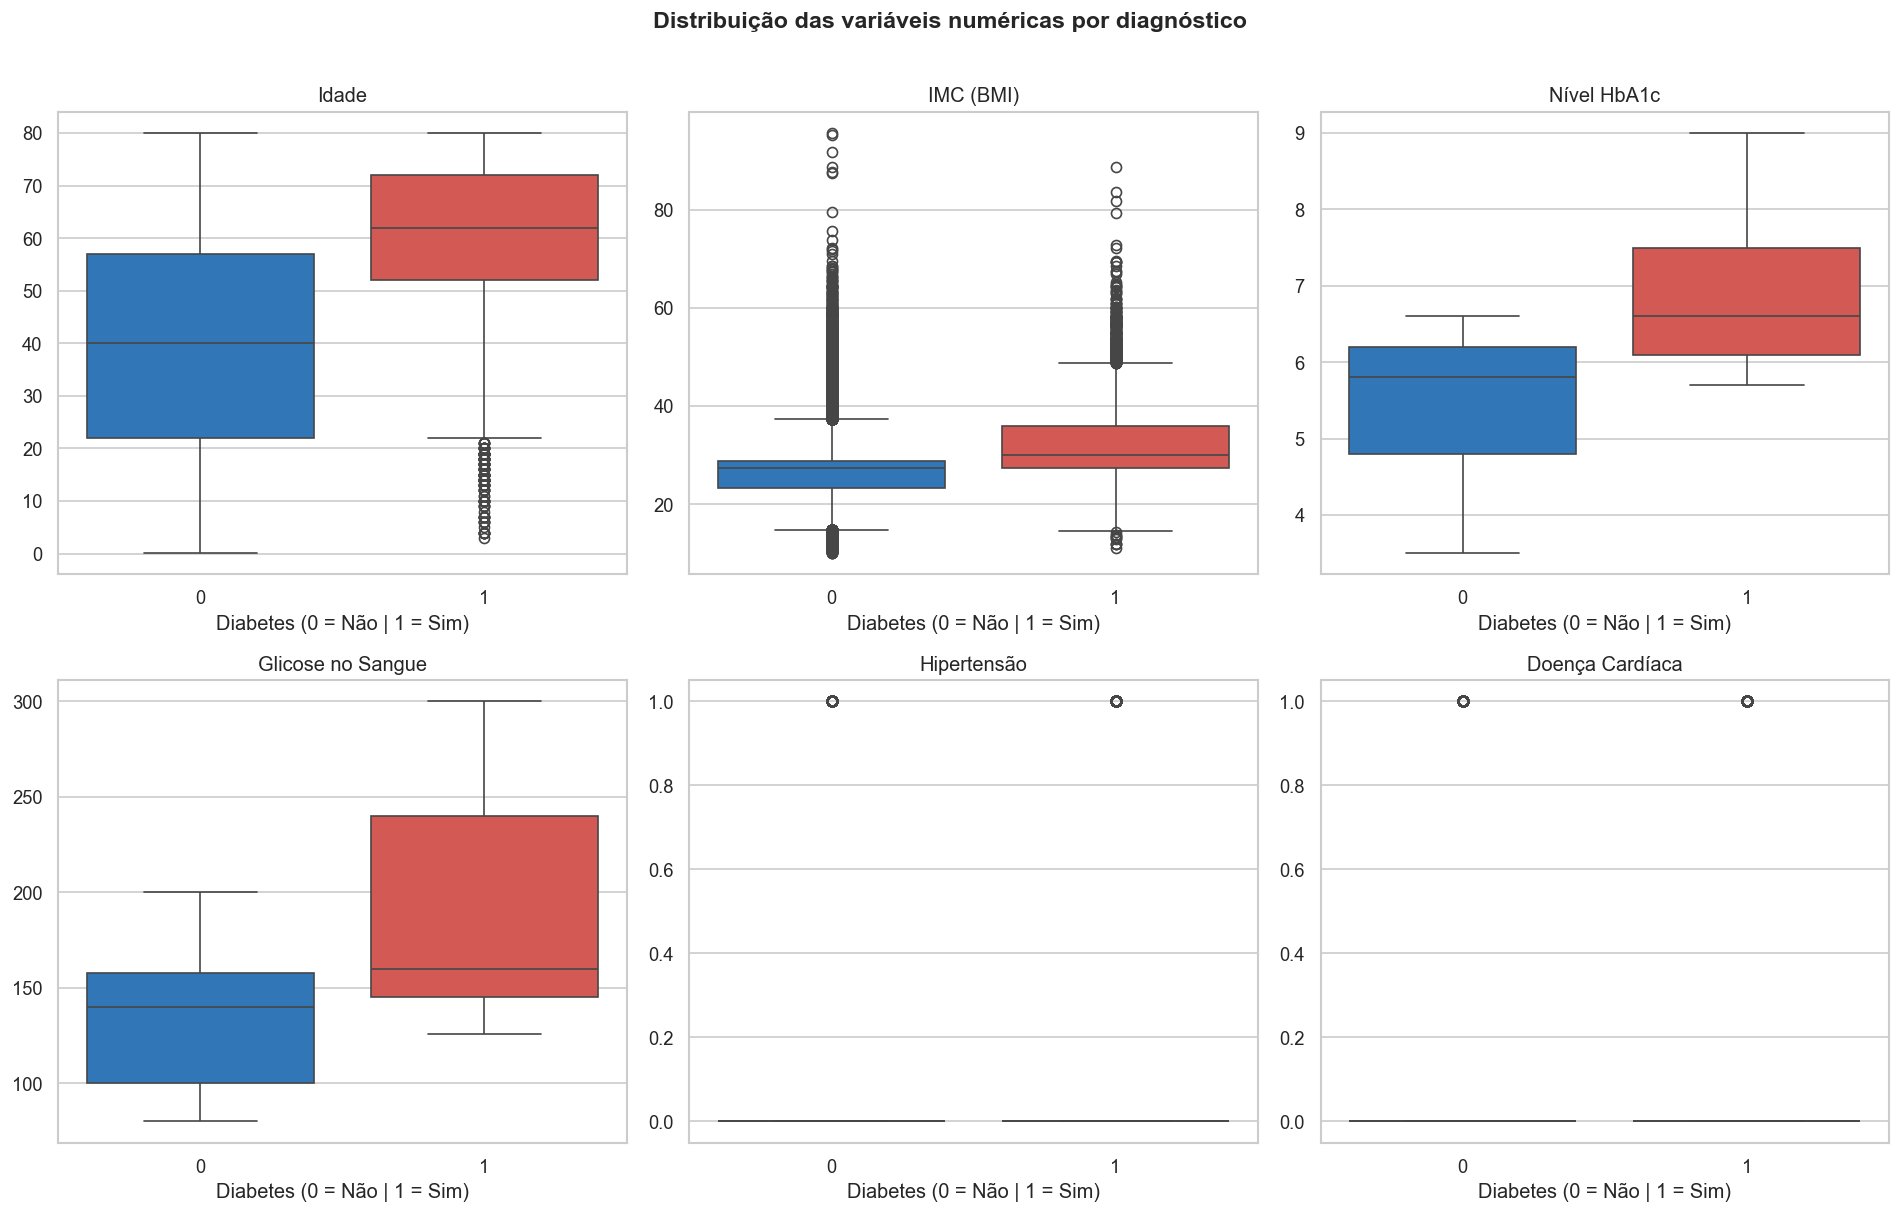

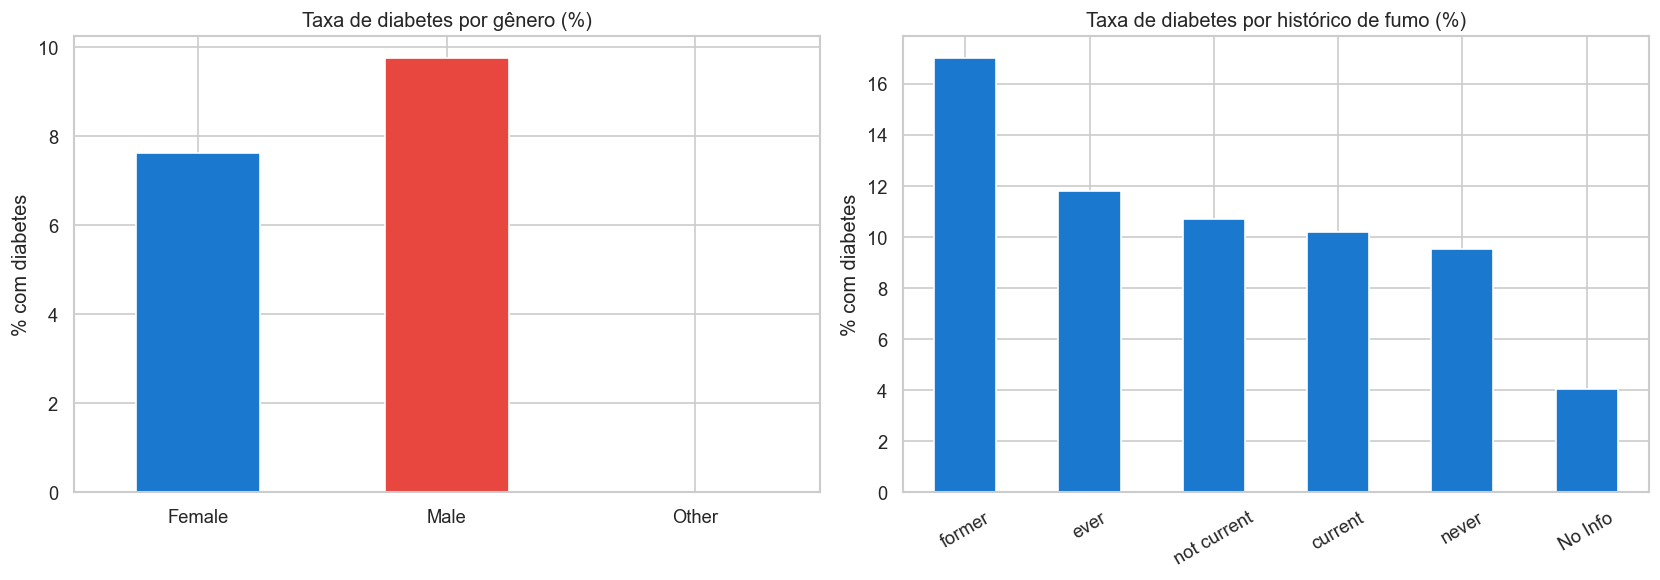

=== CORRELAÇÃO COM DIABETES ===
diabetes               1.000
blood_glucose_level    0.420
HbA1c_level            0.401
age                    0.258
bmi                    0.214
hypertension           0.198
heart_disease          0.172
Name: diabetes, dtype: float64


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Distribuição das variáveis numéricas por diagnóstico", 
             fontsize=14, fontweight="bold", y=1.01)

variaveis = ["age", "bmi", "HbA1c_level", "blood_glucose_level",
             "hypertension", "heart_disease"]

titulos = ["Idade", "IMC (BMI)", "Nível HbA1c", 
           "Glicose no Sangue", "Hipertensão", "Doença Cardíaca"]

for ax, var, titulo in zip(axes.flatten(), variaveis, titulos):
    sns.boxplot(
        data=df,
        x="diabetes",
        y=var,
        palette=["#1a78cf", "#e8473f"],
        ax=ax
    )
    ax.set_title(titulo)
    ax.set_xlabel("Diabetes (0 = Não | 1 = Sim)")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

# Distribuição de variáveis categóricas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gênero vs Diabetes
gender_diabetes = df.groupby("gender")["diabetes"].mean() * 100
gender_diabetes.plot(kind="bar", ax=axes[0], color=["#1a78cf", "#e8473f", "#f0a500"],
                     edgecolor="white", rot=0)
axes[0].set_title("Taxa de diabetes por gênero (%)")
axes[0].set_ylabel("% com diabetes")
axes[0].set_xlabel("")

# Histórico de fumo vs Diabetes
smoking_diabetes = df.groupby("smoking_history")["diabetes"].mean() * 100
smoking_diabetes.sort_values(ascending=False).plot(
    kind="bar", ax=axes[1], color="#1a78cf", edgecolor="white", rot=30)
axes[1].set_title("Taxa de diabetes por histórico de fumo (%)")
axes[1].set_ylabel("% com diabetes")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

# Matriz de correlação
print("=== CORRELAÇÃO COM DIABETES ===")
correlacoes = df.select_dtypes(include=np.number).corr()["diabetes"].sort_values(ascending=False)
print(correlacoes.round(3))

In [5]:
#Categoria sem registros
df = df[df["gender"] != "Other"].copy()
print(f"Registros após remoção de 'Other': {len(df)}")

# Encoding de variáveis categóricas
le_gender = LabelEncoder()
le_smoking = LabelEncoder()

df["gender_encoded"] = le_gender.fit_transform(df["gender"])
df["smoking_encoded"] = le_smoking.fit_transform(df["smoking_history"])

#mapeamento criado
print("\nMapeamento De Gênero")
for original, encoded in zip(le_gender.classes_, range(len(le_gender.classes_))):
    print(f"  {original} → {encoded}")

print("\nMapeamento De Histórico de Fumo")
for original, encoded in zip(le_smoking.classes_, range(len(le_smoking.classes_))):
    print(f"  {original} → {encoded}")

# Definindo features (X) e target (y)
features = ["gender_encoded", "age", "hypertension", "heart_disease",
            "smoking_encoded", "bmi", "HbA1c_level", "blood_glucose_level"]

X = df[features]
y = df["diabetes"]

print(X.columns.tolist())
print(f"\nShape de X: {X.shape}")
print(f"Shape de y: {y.shape}")

# Divisão treino/teste — 80% treino, 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  #mesma proporção de diabéticos em treino e teste
)

print(f"\nDivisão treino/teste")
print(f"Treino: {X_train.shape[0]} registros")
print(f"Teste:  {X_test.shape[0]} registros")

# Padronização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nPré-processamento feito")

Registros após remoção de 'Other': 99982

Mapeamento De Gênero
  Female → 0
  Male → 1

Mapeamento De Histórico de Fumo
  No Info → 0
  current → 1
  ever → 2
  former → 3
  never → 4
  not current → 5
['gender_encoded', 'age', 'hypertension', 'heart_disease', 'smoking_encoded', 'bmi', 'HbA1c_level', 'blood_glucose_level']

Shape de X: (99982, 8)
Shape de y: (99982,)

Divisão treino/teste
Treino: 79985 registros
Teste:  19997 registros

Pré-processamento feito


In [6]:
# Definindo os modelos com class_weight="balanced" pra lidar com desbalanceamento
modelos = {
    "Regressão Logística": LogisticRegression(
        class_weight="balanced", max_iter=1000, random_state=42),
    "Árvore de Decisão": DecisionTreeClassifier(
        class_weight="balanced", max_depth=6, random_state=42),
    "Random Forest": RandomForestClassifier(
        class_weight="balanced", n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100, random_state=42)
}

# Treinamento dos modelos e avaliação
resultados = []

for nome, modelo in modelos.items():
    # Treina o modelo
    modelo.fit(X_train_scaled, y_train)
    
    # Faz previsões no conjunto de teste
    y_pred = modelo.predict(X_test_scaled)
    y_prob = modelo.predict_proba(X_test_scaled)[:, 1]
    
    # Métricas
    report = classification_report(y_test, y_pred, output_dict=True)
    auc    = roc_auc_score(y_test, y_prob)
    
    resultados.append({
        "Modelo":    nome,
        "Acurácia":  round(report["accuracy"] * 100, 2),
        "Precision": round(report["1"]["precision"] * 100, 2),
        "Recall":    round(report["1"]["recall"] * 100, 2),
        "F1-Score":  round(report["1"]["f1-score"] * 100, 2),
        "ROC-AUC":   round(auc * 100, 2)
    })
    print(f"✓ {nome} treinado")

# Tabela comparativa
df_resultados = pd.DataFrame(resultados).set_index("Modelo")
print("\n=== COMPARAÇÃO DE MODELOS ===")
display(df_resultados)

✓ Regressão Logística treinado
✓ Árvore de Decisão treinado
✓ Random Forest treinado
✓ Gradient Boosting treinado

=== COMPARAÇÃO DE MODELOS ===


,Acurácia,Precision,Recall,F1-Score,ROC-AUC
Modelo,,,,,
Regressão Logística,88.71,42.16,88.24,57.06,96.20
Árvore de Decisão,86.19,37.43,92.94,53.37,96.98
Random Forest,97.00,94.22,69.00,79.66,96.37
Gradient Boosting,97.24,98.40,68.71,80.91,97.95


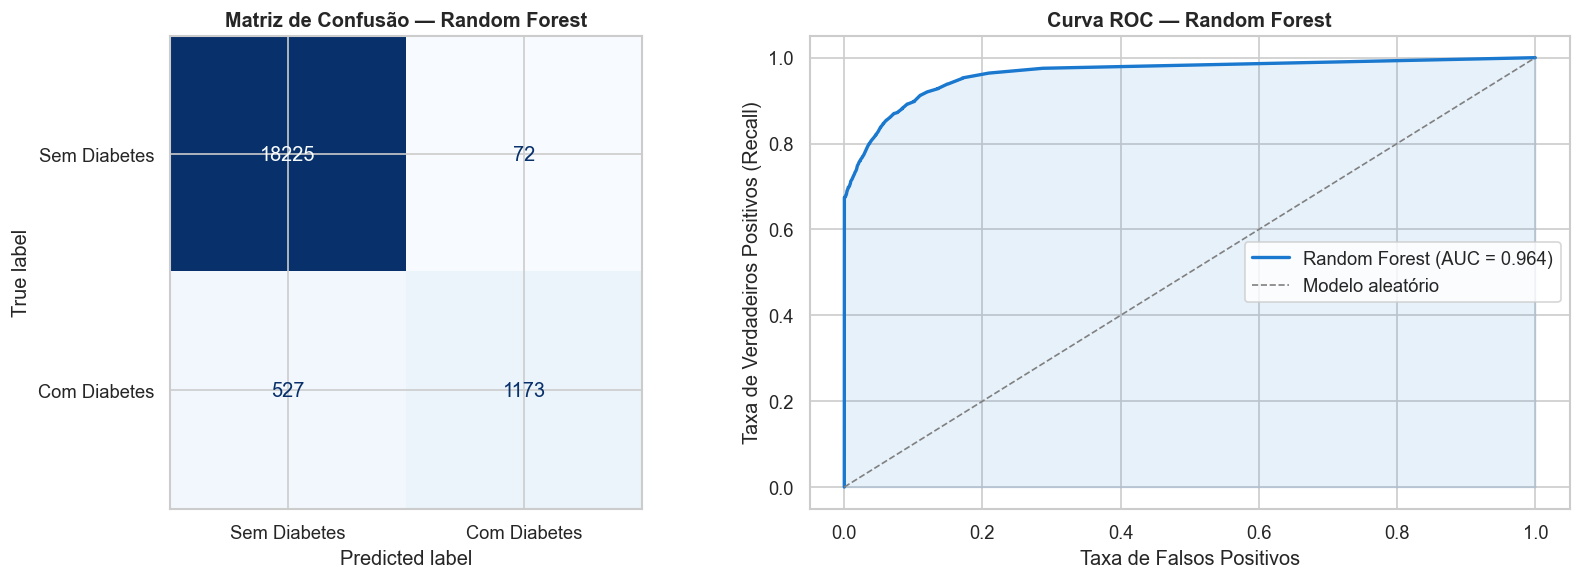

Classificação — Random Forest

              precision    recall  f1-score   support

Sem Diabetes       0.97      1.00      0.98     18297
Com Diabetes       0.94      0.69      0.80      1700

    accuracy                           0.97     19997
   macro avg       0.96      0.84      0.89     19997
weighted avg       0.97      0.97      0.97     19997

Verdadeiros Negativos (acertou sem diabetes):  18225
Falsos Positivos (disse diabetes, não tinha):  72
Falsos Negativos (perdeu diabético real):      527
Verdadeiros Positivos (acertou diabético):     1173


In [7]:
# Random Forest ->
modelo_final = modelos["Random Forest"]
y_pred_final = modelo_final.predict(X_test_scaled)
y_prob_final = modelo_final.predict_proba(X_test_scaled)[:, 1]

#Matriz de confusão
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=["Sem Diabetes", "Com Diabetes"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusão — Random Forest", fontweight="bold")

#Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_final)
auc_score   = roc_auc_score(y_test, y_prob_final)

axes[1].plot(fpr, tpr, color="#1a78cf", lw=2, 
             label=f"Random Forest (AUC = {auc_score:.3f})")
axes[1].plot([0, 1], [0, 1], color="gray", lw=1, 
             linestyle="--", label="Modelo aleatório")
axes[1].fill_between(fpr, tpr, alpha=0.1, color="#1a78cf")
axes[1].set_xlabel("Taxa de Falsos Positivos")
axes[1].set_ylabel("Taxa de Verdadeiros Positivos (Recall)")
axes[1].set_title("Curva ROC — Random Forest", fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

# Relatório de classificação
print("Classificação — Random Forest\n")
print(classification_report(y_test, y_pred_final, 
      target_names=["Sem Diabetes", "Com Diabetes"]))

# Números absolutos da matriz
tn, fp, fn, tp = cm.ravel()
print(f"Verdadeiros Negativos (acertou sem diabetes):  {tn}")
print(f"Falsos Positivos (disse diabetes, não tinha):  {fp}")
print(f"Falsos Negativos (perdeu diabético real):      {fn}")
print(f"Verdadeiros Positivos (acertou diabético):     {tp}")

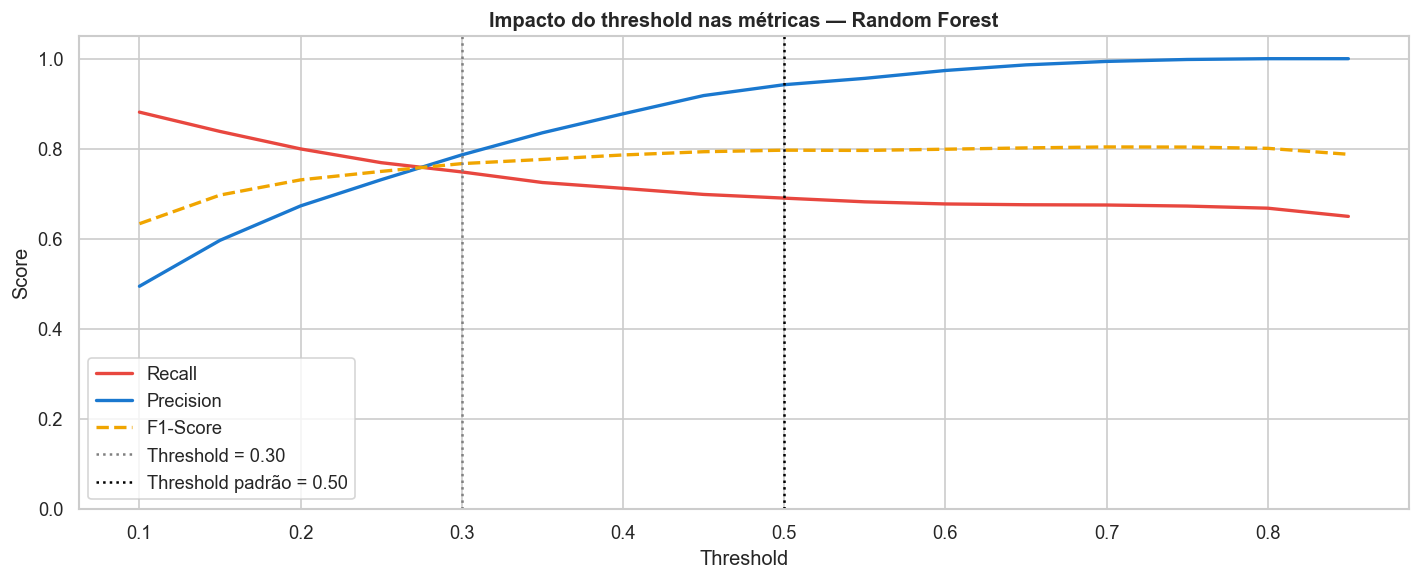

Threshold Padrão (0.50)
              precision    recall  f1-score   support

Sem Diabetes       0.97      1.00      0.98     18297
Com Diabetes       0.94      0.69      0.80      1700

    accuracy                           0.97     19997
   macro avg       0.95      0.84      0.89     19997
weighted avg       0.97      0.97      0.97     19997

Threshold Ajustado (0.30)
              precision    recall  f1-score   support

Sem Diabetes       0.98      0.98      0.98     18297
Com Diabetes       0.78      0.75      0.76      1700

    accuracy                           0.96     19997
   macro avg       0.88      0.87      0.87     19997
weighted avg       0.96      0.96      0.96     19997


Com threshold 0.30:
Diabéticos detectados:      1278 de 1700 (75.2%)
Falsos alarmes gerados:     371
Diabéticos que escaparam:   422


In [8]:
thresholds = np.arange(0.1, 0.9, 0.05)

recalls    = []
precisions = []
f1s        = []

for t in thresholds:
    y_pred_t = (y_prob_final >= t).astype(int)
    report   = classification_report(y_test, y_pred_t, 
                                     output_dict=True, zero_division=0)
    recalls.append(report["1"]["recall"])
    precisions.append(report["1"]["precision"])
    f1s.append(report["1"]["f1-score"])

# Gráfico
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(thresholds, recalls,    label="Recall",    color="#e8473f", lw=2)
ax.plot(thresholds, precisions, label="Precision", color="#1a78cf", lw=2)
ax.plot(thresholds, f1s,        label="F1-Score",  color="#f0a500", lw=2, linestyle="--")

ax.axvline(x=0.3, color="gray", linestyle=":", lw=1.5, label="Threshold = 0.30")
ax.axvline(x=0.5, color="black", linestyle=":", lw=1.5, label="Threshold padrão = 0.50")

ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Impacto do threshold nas métricas — Random Forest", fontweight="bold")
ax.legend()
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

# Comparando threshold 0.50 vs 0.30
print("Threshold Padrão (0.50)")
y_pred_50 = (y_prob_final >= 0.50).astype(int)
print(classification_report(y_test, y_pred_50, 
      target_names=["Sem Diabetes", "Com Diabetes"]))

print("Threshold Ajustado (0.30)")
y_pred_30 = (y_prob_final >= 0.30).astype(int)
print(classification_report(y_test, y_pred_30, 
      target_names=["Sem Diabetes", "Com Diabetes"]))

# Impacto em números absolutos
tn30, fp30, fn30, tp30 = confusion_matrix(y_test, y_pred_30).ravel()
print(f"\nCom threshold 0.30:")
print(f"Diabéticos detectados:      {tp30} de {tp30+fn30} ({tp30/(tp30+fn30)*100:.1f}%)")
print(f"Falsos alarmes gerados:     {fp30}")
print(f"Diabéticos que escaparam:   {fn30}")

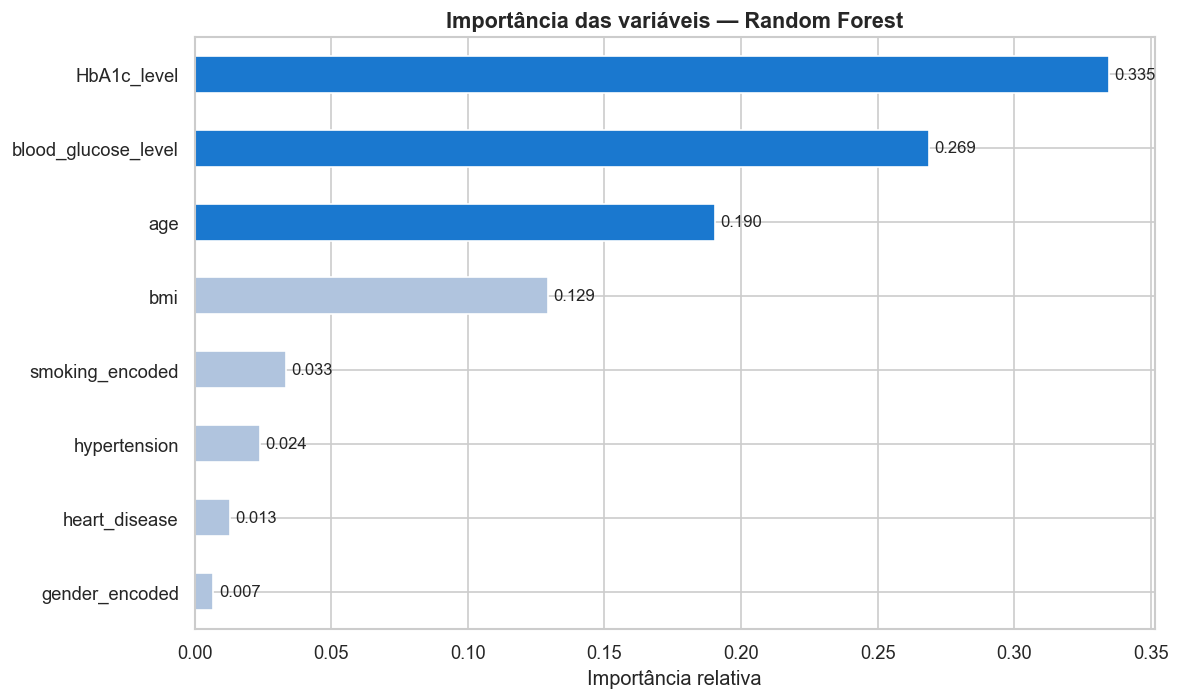

Importância das Variáveis — Random Forest

  HbA1c_level              : 0.3347 (33.5%)
  blood_glucose_level      : 0.2689 (26.9%)
  age                      : 0.1903 (19.0%)
  bmi                      : 0.1292 (12.9%)
  smoking_encoded          : 0.0335 (3.3%)
  hypertension             : 0.0238 (2.4%)
  heart_disease            : 0.0128 (1.3%)
  gender_encoded           : 0.0069 (0.7%)


In [9]:
# Extraindo importância das variáveis
importancias = pd.Series(
    modelo_final.feature_importances_,
    index=features
).sort_values(ascending=True)

# Gráfico
fig, ax = plt.subplots(figsize=(10, 6))

cores = ["#1a78cf" if i >= len(importancias) - 3 
         else "#b0c4de" for i in range(len(importancias))]

importancias.plot(kind="barh", ax=ax, color=cores, edgecolor="white")

ax.set_title("Importância das variáveis — Random Forest", 
             fontweight="bold", fontsize=13)
ax.set_xlabel("Importância relativa")
ax.set_ylabel("")

#Valores nas barras
for i, (val, name) in enumerate(zip(importancias.values, importancias.index)):
    ax.text(val + 0.002, i, f"{val:.3f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

print("Importância das Variáveis — Random Forest\n")
for feat, imp in importancias.sort_values(ascending=False).items():
    print(f"  {feat:25s}: {imp:.4f} ({imp*100:.1f}%)")

In [10]:
import joblib

# Salvando o modelo treinado para publicação em streamlit
joblib.dump(modelo_final, "diabetes_model.pkl")

# Salvando o scaler
# Obs: O app precisa usar o mesmo scaler do treino
joblib.dump(scaler, "diabetes_scaler.pkl")

# Salvando o mapeamento do histórico de fumo
# O app vai precisar converter o texto do usuário pro número correto
smoking_mapping = {
    original: encoded 
    for original, encoded in zip(le_smoking.classes_, range(len(le_smoking.classes_)))
}
joblib.dump(smoking_mapping, "smoking_mapping.pkl")

print("Arquivos salvos:")
print("  diabetes_model.pkl   — modelo Random Forest")
print("  diabetes_scaler.pkl  — scaler de padronização")
print("  smoking_mapping.pkl  — mapeamento de histórico de fumo")
print(f"\nMapeamento de fumo: {smoking_mapping}")

Arquivos salvos:
  diabetes_model.pkl   — modelo Random Forest
  diabetes_scaler.pkl  — scaler de padronização
  smoking_mapping.pkl  — mapeamento de histórico de fumo

Mapeamento de fumo: {'No Info': 0, 'current': 1, 'ever': 2, 'former': 3, 'never': 4, 'not current': 5}
